# **Project: FoodHub (Uber Eats, USA) - Exploratory Data Analysis**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import Libraries for data manipulation
import numpy as np
import pandas as pd

# import Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
# import the data
df = pd.read_csv('/content/drive/MyDrive/Gen AI/foodhub_order.csv')
#returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


# **Structure of the data: row & columns:**

In [4]:
print(df.shape)

(1898, 9)


In [5]:
print("rows:", df.shape[0])
print("column:", df.shape[1])

rows: 1898
column: 9


# **Details of all columns and their datatypes:**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


# **Chech if there are any missing values:**

In [7]:
missing_recs = df.isnull().sum()
print(missing_recs)

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


# **Stastical summary of the data:**

In [8]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


# **Find out how many orders are rated and not rated:**

In [9]:
#find how many orders are havinf rating
orders_ratings = df['rating'].value_counts().drop('Not given')
print(orders_ratings)

rating
5    588
4    386
3    188
Name: count, dtype: int64


In [10]:
#find how many orders are havinf rating
not_rated = df[df['rating'] == 'Not given'].value_counts().sum()
print(not_rated)

736


# **Display the number of orders per restaurant:**

In [11]:
#method 1
orders = pd.DataFrame(df['restaurant_name'].value_counts())
print(orders)

                           count
restaurant_name                 
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
...                          ...
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1

[178 rows x 1 columns]


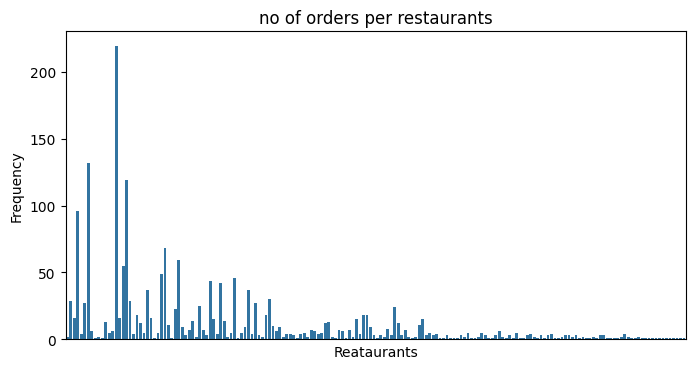

In [12]:
#no of orders per restaurants
plt.figure(figsize = (8,4))
sns.countplot(x = df['restaurant_name'])

#plotting no of orders per reataurants
plt.title('no of orders per restaurants')
plt.xlabel('Reataurants')
plt.xticks([])
#plt.xticks(rotation = 30)
plt.ylabel('Frequency')
plt.show()

In [13]:
#method 2
orders_per_restaurant = df.groupby('restaurant_name').size()
print(orders_per_restaurant)

restaurant_name
'wichcraft           1
12 Chairs            4
5 Napkin Burger      5
67 Burger            1
Alidoro              1
                    ..
Zero Otto Nove       2
brgr                 2
da Umberto           3
ilili Restaurant    18
indikitch            4
Length: 178, dtype: int64


In [15]:
# Display the list of restaurants with just one order:
single_order_restaurants = orders_per_restaurant[orders_per_restaurant == 1]
print(single_order_restaurants.sum())

50


**Inference:** There are a total of 178 restaurants. The restaurant with the most number of orders is Slake Shack with 219 orders. There are 50 restaurants with just one order.

# **Plot the number of orders per cuisine type using a bar or count plot, and pie chart. Also write your findings/inferences:**

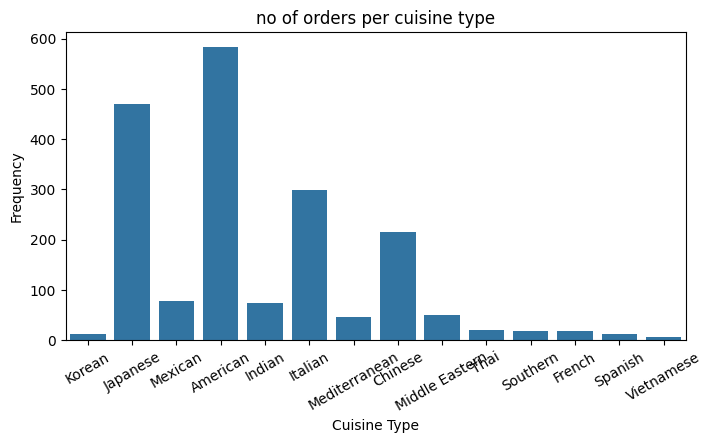

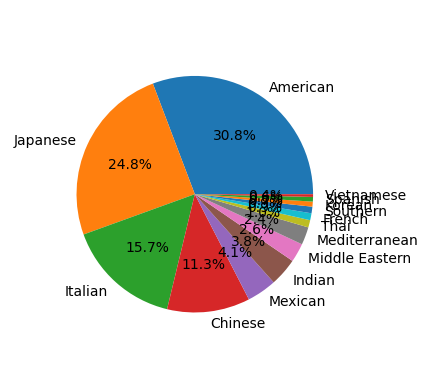

In [ ]:
#no of orders per cuisine type

#countplot
plt.figure(figsize = (8,4))
sns.countplot(x = df['cuisine_type'])
plt.title('no of orders per cuisine type')
plt.xlabel('Cuisine Type')
plt.xticks(rotation=30)
plt.ylabel('Frequency')
plt.show()

#pie plot
labels = list(df['cuisine_type'].value_counts().index)
plt.pie(df['cuisine_type'].value_counts(), labels=labels, autopct='%.1f%%', radius=0.8)
plt.show()

**Inference:** American cuisine is the most popular with 30.8% and the Japanese is second most popular with 24.8%, and the least is Vietnamese with 0.4%

# **Find the minimum, maximum and median Cost of the Orders using distribution plots and box plots and write your inferences:**

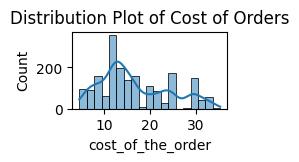

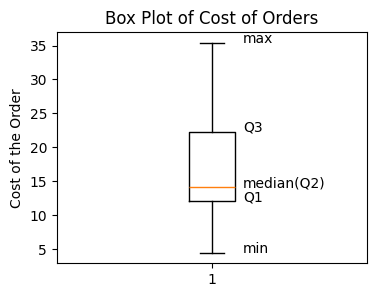

In [ ]:
#Cost of orders
#Distribution plot
plt.figure(figsize=(2,1))
sns.histplot(data = df, x='cost_of_the_order',kde=True)
plt.title('Distribution Plot of Cost of Orders')
plt.show()

#Box plot
plt.figure(figsize=(4,3))
plt.boxplot(df['cost_of_the_order'])
plt.text(x=1.1,y=df['cost_of_the_order'].min(), s='min')
plt.text(x=1.1,y=df['cost_of_the_order'].quantile(0.25), s='Q1')
plt.text(x=1.1,y=df['cost_of_the_order'].median(), s='median(Q2)')
plt.text(x=1.1,y=df['cost_of_the_order'].quantile(0.75), s='Q3')
plt.text(x=1.1,y=df['cost_of_the_order'].max(), s='max')

plt.title('Box Plot of Cost of Orders')
plt.ylabel('Cost of the Order')
plt.show()

In [ ]:
#Inference
print('Minimum cost of the order:', df['cost_of_the_order'].min())
print('Maximum cost of the order:', df['cost_of_the_order'].max())
print('Median cost of the order:', df['cost_of_the_order'].median())

Minimum cost of the order: 4.47
Maximum cost of the order: 35.41
Median cost of the order: 14.14


# **Plot the number of orders per Day of the Week using a count plot and pie chart and write your inferences:**

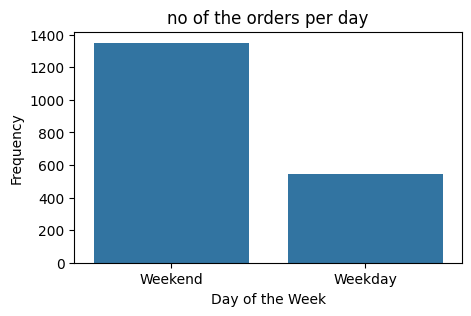

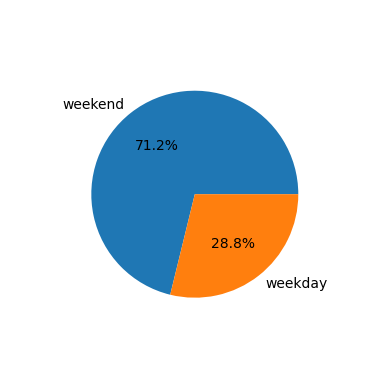

In [ ]:
#no of the orders per day

#count plot
plt.figure(figsize = (5,3))
sns.countplot(x = df['day_of_the_week'])
plt.title('no of the orders per day')
plt.xlabel('Day of the Week')
plt.ylabel('Frequency')
plt.show()

#Box plot
labels = ['weekend','weekday']
plt.pie(df['day_of_the_week'].value_counts(), labels=labels, autopct='%.1f%%', radius=0.7)
plt.show()

In [ ]:
#count the no of the orders in "day of the week"
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


**Inference:** There are 1351 orders placed during the Weekends and 547 orders placed during the Weekdays.

# **Display the count of Ratings and plot them using count plot and pie chart and write your inferences:**

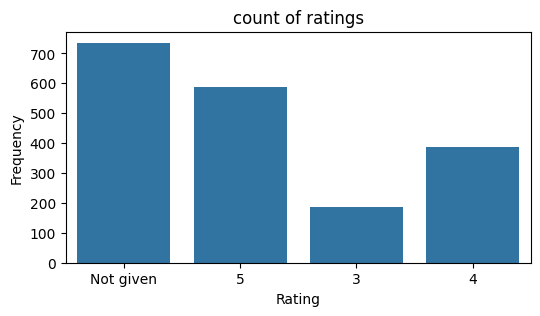

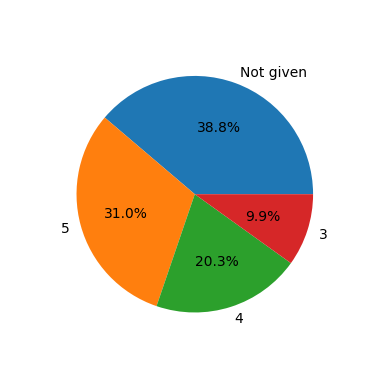

In [ ]:
#count of ratings:

#count plot:
plt.figure(figsize = (6,3))
sns.countplot(x = df['rating'])
plt.title('count of ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

#pie plot
labels = ['Not given','5','4','3']
plt.pie(df['rating'].value_counts(), labels=labels, autopct='%.1f%%', radius=0.8)
plt.show()

In [ ]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


**Inference:** There are 736 orders with a rating of "Not Given". There are 588 orders with a rating of 5 There are 386 orders with a rating of 4 There are 188 orders with a rating of 3

# **Find the min, max and median Food preparation time and also plot them using a distribution plot and box plot. Write your inferences:**

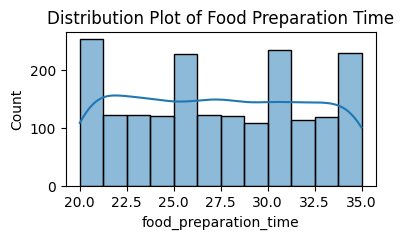

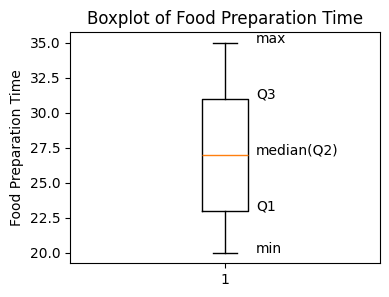

In [ ]:
#food prearation time
#distribution plot
plt.figure(figsize=(4,2))
sns.histplot(data = df, x='food_preparation_time',kde=True)
plt.title('Distribution Plot of Food Preparation Time')
plt.show()

#Box plot
plt.figure(figsize=(4,3))
plt.boxplot(df['food_preparation_time'])
plt.text(x=1.1,y=df['food_preparation_time'].min(), s='min')
plt.text(x=1.1,y=df['food_preparation_time'].quantile(0.25), s='Q1')
plt.text(x=1.1,y=df['food_preparation_time'].median(), s='median(Q2)')
plt.text(x=1.1,y=df['food_preparation_time'].quantile(0.75), s='Q3')
plt.text(x=1.1,y=df['food_preparation_time'].max(), s='max')
plt.title('Boxplot of Food Preparation Time')
plt.ylabel('Food Preparation Time')
plt. show()

In [ ]:
#Inference
print('Minimum food preparation time:', df['food_preparation_time'].min())
print('Maximum food preparation time:', df['food_preparation_time'].max())
print('Median food preparation time:', df['food_preparation_time'].median())

Minimum food preparation time: 20
Maximum food preparation time: 35
Median food preparation time: 27.0


# **Find the min, max and median Delivery Time and also plot them using a distribution plot and box plot. Write your inferences:**

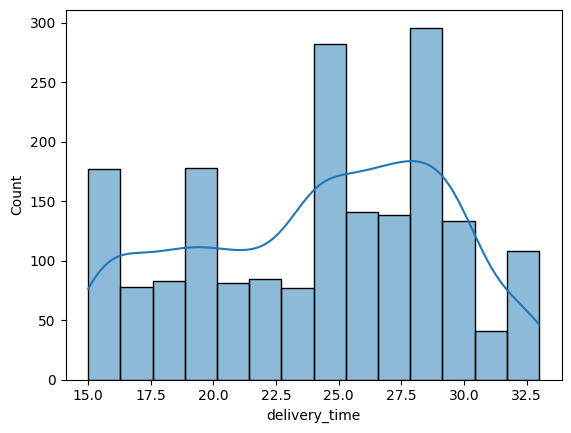

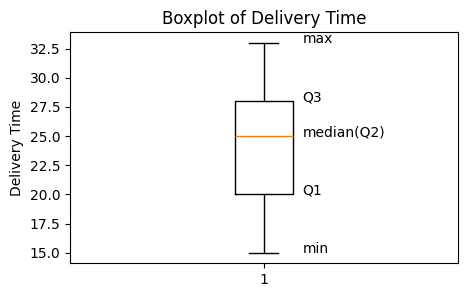

In [ ]:
# Delivery Time:
# Distribution plot
sns.histplot(data=df, x='delivery_time', kde=True)
plt.show()

# Box plot
plt.figure(figsize=(5,3))
plt.boxplot(df['delivery_time'])
plt.text(x=1.1,y=df['delivery_time'].min(), s='min')
plt.text(x=1.1,y=df['delivery_time'].quantile(0.25), s='Q1')
plt.text(x=1.1,y=df['delivery_time'].median(), s='median(Q2)')
plt.text(x=1.1,y=df['delivery_time'].quantile(0.75), s='Q3')
plt.text(x=1.1,y=df['delivery_time'].max(), s='max')

plt.title('Boxplot of Delivery Time')
plt.ylabel( 'Delivery Time')
plt. show()

In [ ]:
#Inference
print('Minimum delivery time:', df['delivery_time'].min())
print('Maximum delivery time:', df['delivery_time'].max())
print('Median delivery time:', df['delivery_time'].median())

Minimum delivery time: 15
Maximum delivery time: 33
Median delivery time: 25.0


# **What are the top 5 restaurants in terms of the number of orders received:**

In [ ]:
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


# **Which is the most popular cuisine on weekends:**

In [ ]:
df_weekend = df[df['day_of_the_week']== 'Weekend']
df_weekend['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


'American' is the most popular cuisine ordered on weekends.

# **Which is the most popular cuisine on weekdays:**

In [ ]:
df_weekend = df[df['day_of_the_week']== 'Weekday']
df_weekend['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,169
Japanese,135
Italian,91
Chinese,52
Mexican,24


In the Weekdays as well, 'American' is the most popular cuisines.

# **What percentage of the orders cost more than 20 dollars?**

In [ ]:
#create a dataset of orders grether than 20.
orders_more_than_20 = df[df['cost_of_the_order'] > 20]
percent_20usd = (orders_more_than_20.shape[0] / df.shape[0]) * 100
percent_20usd

29.24130663856691

# **What is the mean order delivery time?**

In [ ]:
#mean delivery time
df['food_preparation_time'].mean() + df['delivery_time'].mean()

np.float64(51.53371970495259)

The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed:

In [ ]:
df['customer_id'].value_counts().head()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


# **Plot the distribution of Cost of Order per Day of the Week (Weekdays and Weekends):**

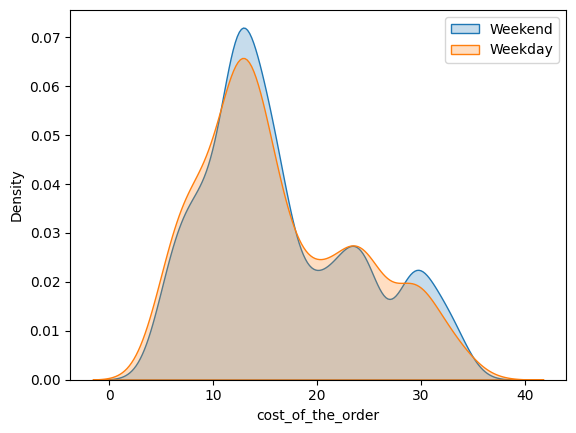

In [ ]:
day = ['Weekend', 'Weekday']
#iterate through time
for x in day:
  subset = df[df[ 'day_of_the_week'] == x]
  sns.distplot(subset[ 'cost_of_the_order'], hist = False, kde = True, kde_kws = {'shade': True}, label =labels)
plt.legend (labels=day)

# **Plot the Food preparation Times on Weekdays and Weekends and infer your results:**

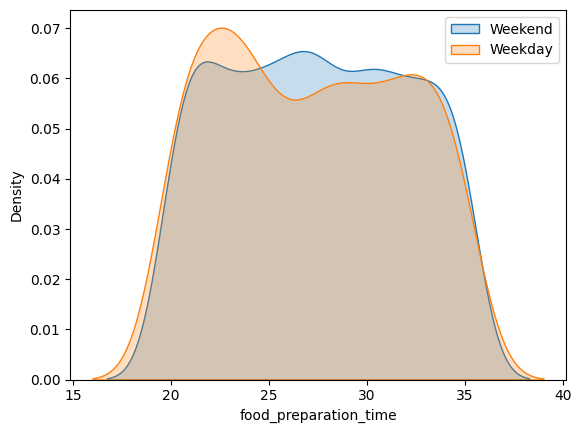

In [ ]:
day = ['Weekend', 'Weekday']
#iterate through time
for x in day:
  subset = df[df[ 'day_of_the_week'] == x]
  sns.distplot(subset[ 'food_preparation_time'], hist = False, kde = True, kde_kws = {'shade': True}, label =labels)
plt.legend (labels=day)

**Inference:** The food preparation time appears to be shorter during the weekdays than the weekends

# **Plot the Delivery Time on Weekdays and Weekends and infer your results:**

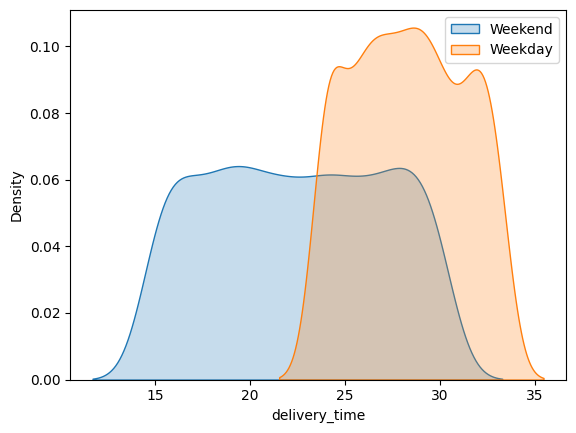

In [ ]:
day = ['Weekend', 'Weekday']
#iterate through time
for x in day:
  subset = df[df[ 'day_of_the_week'] == x]
  sns.distplot(subset[ 'delivery_time'], hist = False, kde = True, kde_kws = {'shade': True}, label =labels)
plt.legend (labels=day)

**Inference:** Delivery time seems to take longer during the weekdays than weekends.

# **Plot Cost of the Order per Cuisine type using a box plot and infer your results:**

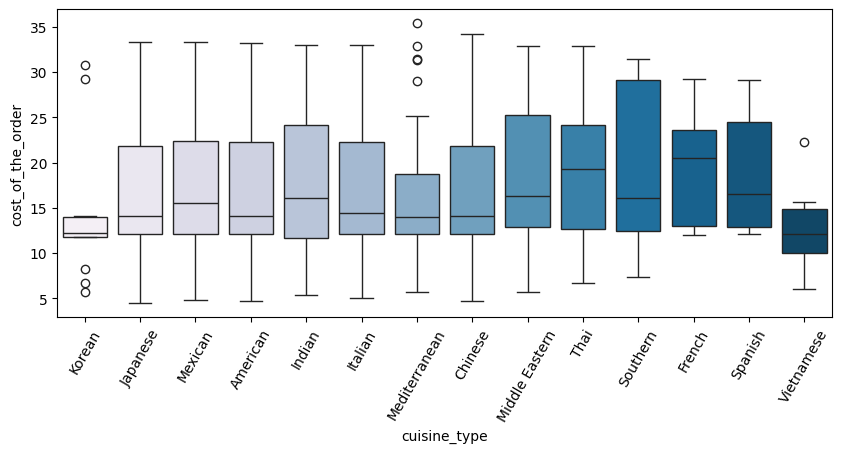

In [ ]:
# plot of cost of the order and cuisine type
plt.figure(figsize=(10,4))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show()

**Inference:** Middle Eastern & Southern foods seem to cost highest, while Korean and Vietnamese the lowest.

# **Plot the relationship between day of the week and delivery time using box plot:**

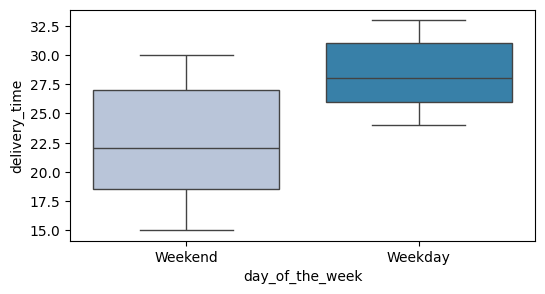

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette = 'PuBu' )
plt.show()